In [1]:
import os, ROOT as r
import uproot
import numpy as np
import matplotlib.pyplot as plt
base = os.path.expandvars("$HOME/roohill/standalone")
r.gInterpreter.AddIncludePath(os.path.join(base, "include"))
r.gSystem.Load(os.path.join(base, "libRooHILLdini.so"))

Welcome to JupyROOT 6.30/02



0

In [2]:
import ROOT as r

TREE_PATH = "Tuple/DecayTree"
FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/2024/Bd2DK_24c4a_up_final.root",
]

chain = r.TChain(TREE_PATH)
for f in FILES:
    chain.Add(f)

print("✅ Added files:", chain.GetListOfFiles().GetEntries())
print("✅ Total entries in chain:", chain.GetEntries())

✅ Added files: 2
✅ Total entries in chain: 543117



Error in <TFile::TFile>: file /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/2024/Bd2DK_24c4a_up_final.root does not exist



In [3]:
import ROOT as r

TREE_PATH = "Tuple/DecayTree"
chain = r.TChain(TREE_PATH)
for f in FILES:
    chain.Add(f)

print("✅ Added files:", chain.GetListOfFiles().GetEntries())
print("✅ Total entries in chain:", chain.GetEntries())

# Ensure a tree is loaded so we can inspect its structure
if chain.GetEntries() == 0:
    raise RuntimeError("Chain has no entries — cannot list branches.")
chain.LoadTree(0)
tree = chain.GetTree()
if not tree:
    raise RuntimeError("Failed to access underlying TTree from TChain.")

branches = tree.GetListOfBranches()
print("✅ Number of branches:", branches.GetEntries())

def leaf_type(leaf):
    # best-effort type name
    t = leaf.GetTypeName()
    if t: 
        return t
    # fallback using title
    return leaf.GetTitle().split("/")[-1] if "/" in leaf.GetTitle() else "?"

# Print a tidy list: branch → leaves (with types)
for b in branches:
    bname = b.GetName()
    bcls  = b.GetClassName()  # non-empty for object branches
    leaves = b.GetListOfLeaves()
    if bcls:
        # e.g. TLorentzVector or std::vector<double>
        print(f"• {bname}  (class: {bcls})")
    elif leaves and leaves.GetEntries() == 1:
        lf = leaves.At(0)
        print(f"• {bname}  [{leaf_type(lf)}]")
    else:
        print(f"• {bname}")
        for lf in leaves:
            print(f"    └─ {lf.GetName()}  [{leaf_type(lf)}]")

# (Optional) also list aliases if the tree has any
aliases = tree.GetListOfAliases()
if aliases and aliases.GetEntries() > 0:
    print("\nAliases:")
    for a in aliases:
        print(f"• {a.GetName()} = {tree.GetAlias(a.GetName())}")


✅ Added files: 2
✅ Total entries in chain: 543117
✅ Number of branches: 292
• EVENTNUMBER  [ULong64_t]
• Hlt1TrackMVADecision  [Bool_t]
• Hlt1TwoTrackMVADecision  [Bool_t]
• Hlt1_TCK  [UInt_t]
• Hlt2B2OC_BdToDmK_DmToPimPimKpDecision  [Bool_t]
• Hlt2Topo2BodyDecision  [Bool_t]
• Hlt2Topo3BodyDecision  [Bool_t]
• Hlt2_TCK  [UInt_t]
• RUNNUMBER  [UInt_t]
• lab0_BPVCHI2DOF  [Double_t]
• lab0_BPVDIRA  [Float_t]
• lab0_BPVFD  [Float_t]
• lab0_BPVFDCHI2  [Float_t]
• lab0_BPVIP  [Float_t]
• lab0_BPVIPCHI2  [Float_t]
• lab0_BPVLTIME  [Float_t]
• lab0_BPVX  [Float_t]
• lab0_BPVY  [Float_t]
• lab0_BPVZ  [Float_t]
• lab0_CHI2DOF  [Double_t]
• lab0_CHILD1_FDCHI2wrtSV  [Float_t]
• lab0_CHILD1_FDwrtSV  [Float_t]
• lab0_CHILD1_IPCHI2wrtSV  [Float_t]
• lab0_CHILD1_IPwrtSV  [Float_t]
• lab0_DTF_LifetimeFit_CHI2DOF  [Double_t]
• lab0_DTF_LifetimeFit_CTAU  [Double_t]
• lab0_DTF_LifetimeFit_CTAUERR  [Double_t]
• lab0_DTF_LifetimeFit_MASS  [Double_t]
• lab0_DTF_MassFitConsD_CHI2DOF  [Double_t]
• lab0_DTF_Ma

Error in <TFile::TFile>: file /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/2024/Bd2DK_24c4a_up_final.root does not exist



In [4]:
import ROOT as r

TREE_PATH = "Tuple/DecayTree"
FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_up_final.root",
]

for path in FILES:
    print(f"\n🔹 Checking file: {path}")

    f = r.TFile.Open(path)
    if not f or f.IsZombie():
        print("  ❌ Could not open file")
        continue

    tree = f.Get(TREE_PATH)
    if not tree:
        print(f"  ❌ Tree '{TREE_PATH}' not found in file")
        f.Close()
        continue

    n_entries = tree.GetEntries()

    # Fast & memory-safe: ROOT computes min/max internally
    run_min = int(tree.GetMinimum("RUNNUMBER"))
    run_max = int(tree.GetMaximum("RUNNUMBER"))

    print(f"  ✅ Entries           : {n_entries}")
    print(f"  📊 RUNNUMBER range   : {run_min} – {run_max}")

    f.Close()



🔹 Checking file: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root
  ✅ Entries           : 543117
  📊 RUNNUMBER range   : 307589 – 308098

🔹 Checking file: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_up_final.root
  ✅ Entries           : 327189
  📊 RUNNUMBER range   : 308105 – 308540



In [8]:
tree_path  = "Tuple/DecayTree"
mva_branch = "lab0_MVA"
mass_branch = "lab0_MASS"

# =====================================================
# 2) Define signal & background using mass windows
#    (change these numbers to your preferred ranges)
# =====================================================

# Example: Bd mass ~ 5280 MeV, pick a tight-ish window
signal_mass_min = 5200.0
signal_mass_max = 5350.0

# Example sidebands for background (two regions)
bkg_sideband1 = (5100.0, 5200.0)
bkg_sideband2 = (5350.0, 5600.0)

# =====================================================
# 3) Load MVA and MASS from all files
# =====================================================

all_mva = []
all_mass = []

for path in FILES:
    print(f"🔹 Loading file: {path}")
    try:
        with uproot.open(path) as f:
            tree = f[tree_path]
            mva_vals = tree[mva_branch].array(library="np")
            mass_vals = tree[mass_branch].array(library="np")

            all_mva.append(mva_vals)
            all_mass.append(mass_vals)

            print(f"   ✅ entries: {tree.num_entries}")

    except Exception as e:
        print(f"   ❌ Error with file: {e}")

all_mva = np.concatenate(all_mva)
all_mass = np.concatenate(all_mass)

print(f"\nTotal events loaded: {len(all_mva)}")

# =====================================================
# 4) Build signal-like and background-like samples
# =====================================================

signal_mask = (all_mass > signal_mass_min) & (all_mass < signal_mass_max)

bkg_mask = (
    ((all_mass > bkg_sideband1[0]) & (all_mass < bkg_sideband1[1])) |
    ((all_mass > bkg_sideband2[0]) & (all_mass < bkg_sideband2[1]))
)

sig_scores = all_mva[signal_mask]
bkg_scores = all_mva[bkg_mask]

print(f"Signal-like events   (mass window): {len(sig_scores)}")
print(f"Background-like events (sidebands): {len(bkg_scores)}")

# Guard against empty samples
if len(sig_scores) == 0 or len(bkg_scores) == 0:
    raise RuntimeError("Signal or background sample is empty – check your mass windows.")

# =====================================================
# 5) Scan MVA thresholds and find best cut
# =====================================================

def find_best_mva_cut(sig_scores, bkg_scores, n_points=200):
    mva_min = min(sig_scores.min(), bkg_scores.min())
    mva_max = max(sig_scores.max(), bkg_scores.max())
    thresholds = np.linspace(mva_min, mva_max, n_points)

    best = {
        "thr": None,
        "sig_eff": None,
        "bkg_eff": None,
        "bkg_rej": None,
        "metric": -np.inf,
    }

    for thr in thresholds:
        sig_eff = np.mean(sig_scores > thr)         # ε_sig
        bkg_eff = np.mean(bkg_scores > thr)         # ε_bkg
        bkg_rej = 1.0 - bkg_eff                     # 1 - ε_bkg
        metric = sig_eff * bkg_rej                  # balance: ε_sig × (1-ε_bkg)

        if metric > best["metric"]:
            best.update(
                thr=thr,
                sig_eff=sig_eff,
                bkg_eff=bkg_eff,
                bkg_rej=bkg_rej,
                metric=metric,
            )

    return thresholds, best

thresholds, best = find_best_mva_cut(sig_scores, bkg_scores, n_points=400)

# =====================================================
# 6) Print result
# =====================================================

print("\n✅ Best MVA cut (maximizing ε_sig × (1 - ε_bkg)):")
print(f"  MVA cut value          : {best['thr']:.4f}")
print(f"  Signal efficiency      : {best['sig_eff']:.3f}")
print(f"  Background efficiency  : {best['bkg_eff']:.3f}")
print(f"  Background rejection   : {best['bkg_rej']:.3f}")
print(f"  Metric (eps_sig * rej) : {best['metric']:.3f}")

🔹 Loading file: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root
   ✅ entries: 543117
🔹 Loading file: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_up_final.root
   ✅ entries: 327189

Total events loaded: 870306
Signal-like events   (mass window): 273876
Background-like events (sidebands): 262532

✅ Best MVA cut (maximizing ε_sig × (1 - ε_bkg)):
  MVA cut value          : 0.9718
  Signal efficiency      : 0.551
  Background efficiency  : 0.431
  Background rejection   : 0.569
  Metric (eps_sig * rej) : 0.314




✅ Best MVA cut (maximizing ε_sig × (1 - ε_bkg)):
  MVA cut value          : 0.9718
  Signal efficiency      : 0.551
  Background efficiency  : 0.431
  Background rejection   : 0.569
  Metric (eps_sig * rej) : 0.314
  ROC AUC                : -0.583



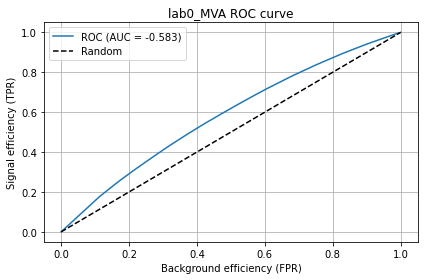

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def scan_mva(sig_scores, bkg_scores, n_points=400):
    """
    Scan MVA thresholds, compute signal eff, background eff (FPR),
    and find the best cut according to eps_sig * (1 - eps_bkg).
    """
    mva_min = min(sig_scores.min(), bkg_scores.min())
    mva_max = max(sig_scores.max(), bkg_scores.max())
    thresholds = np.linspace(mva_min, mva_max, n_points)

    tprs = []   # signal efficiency
    fprs = []   # background efficiency
    best = {
        "thr": None,
        "sig_eff": None,
        "bkg_eff": None,
        "bkg_rej": None,
        "metric": -np.inf,
    }

    for thr in thresholds:
        sig_eff = np.mean(sig_scores > thr)   # TPR
        bkg_eff = np.mean(bkg_scores > thr)   # FPR
        bkg_rej = 1.0 - bkg_eff
        metric = sig_eff * bkg_rej            # your balance criterion

        tprs.append(sig_eff)
        fprs.append(bkg_eff)

        if metric > best["metric"]:
            best.update(
                thr=thr,
                sig_eff=sig_eff,
                bkg_eff=bkg_eff,
                bkg_rej=bkg_rej,
                metric=metric,
            )

    return np.array(thresholds), np.array(tprs), np.array(fprs), best


# === Run the scan ===
thresholds, tprs, fprs, best = scan_mva(sig_scores, bkg_scores, n_points=400)

# Area under ROC: integrate TPR vs FPR
auc = np.trapz(tprs, fprs)

print("\n✅ Best MVA cut (maximizing ε_sig × (1 - ε_bkg)):")
print(f"  MVA cut value          : {best['thr']:.4f}")
print(f"  Signal efficiency      : {best['sig_eff']:.3f}")
print(f"  Background efficiency  : {best['bkg_eff']:.3f}")
print(f"  Background rejection   : {best['bkg_rej']:.3f}")
print(f"  Metric (eps_sig * rej) : {best['metric']:.3f}")
print(f"  ROC AUC                : {auc:.3f}")


# === Quick ROC plot ===
plt.figure()
plt.plot(fprs, tprs, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("Background efficiency (FPR)")
plt.ylabel("Signal efficiency (TPR)")
plt.title("lab0_MVA ROC curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


🔹 Scanning mass range in: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root
🔹 Scanning mass range in: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_up_final.root

📊 Global mass range across all files: 4950.0 – 6000.0 MeV

🔹 Processing file: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root
   ✅ entries: 543117
   passing MVA cut: 495422

🔹 Processing file: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_up_final.root
   ✅ entries: 327189
   passing MVA cut: 298194

Total events passing MVA cut (lab0_MVA > 0.5): 793616



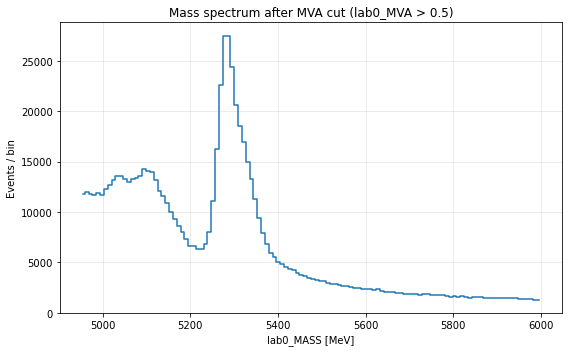

In [13]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# ======================================
# Setup
# ======================================

FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_up_final.root",
]

tree_path   = "Tuple/DecayTree"
mva_branch  = "lab0_MVA"
mass_branch = "lab0_MASS"

# Best MVA (XG) cut from your optimization
MVA_CUT = 0.5

# Number of bins for the histogram (can tune this)
N_BINS = 120

# ======================================
# First pass: determine overall mass range
# ======================================

mass_min, mass_max = np.inf, -np.inf

for path in FILES:
    print(f"🔹 Scanning mass range in: {path}")
    with uproot.open(path) as f:
        tree = f[tree_path]
        mass = tree[mass_branch].array(library="np")
        mass_min = min(mass_min, np.min(mass))
        mass_max = max(mass_max, np.max(mass))

print(f"\n📊 Global mass range across all files: {mass_min:.1f} – {mass_max:.1f} MeV")

# ======================================
# Second pass: apply MVA cut and fill histogram
# ======================================

bin_edges = np.linspace(mass_min, mass_max, N_BINS + 1)
hist_counts = np.zeros(N_BINS, dtype=float)
total_selected = 0

for path in FILES:
    print(f"\n🔹 Processing file: {path}")
    try:
        with uproot.open(path) as f:
            tree = f[tree_path]

            mva  = tree[mva_branch].array(library="np")
            mass = tree[mass_branch].array(library="np")

            mask = mva > MVA_CUT
            mass_sel = mass[mask]
            total_selected += len(mass_sel)

            counts, _ = np.histogram(mass_sel, bins=bin_edges)
            hist_counts += counts

            print(f"   ✅ entries: {tree.num_entries}")
            print(f"   passing MVA cut: {len(mass_sel)}")

    except Exception as e:
        print(f"   ❌ Error: {e}")

print(f"\nTotal events passing MVA cut (lab0_MVA > {MVA_CUT}): {total_selected}")

# ======================================
# Plot
# ======================================

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure(figsize=(8, 5))
plt.step(bin_centers, hist_counts, where="mid", linewidth=1.5)
plt.xlabel("lab0_MASS [MeV]")
plt.ylabel("Events / bin")
plt.title(f"Mass spectrum after MVA cut (lab0_MVA > {MVA_CUT})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



📊 Global mass range: 4950.0 – 6000.0 MeV

🔹 Processing file: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root

🔹 Processing file: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_up_final.root

Total events after MVA cut & in misID region (0.0 < lab1_PIDK < 5.0): 161738
Total events after MVA cut & in kaon region (lab1_PIDK > 5.0): 232928



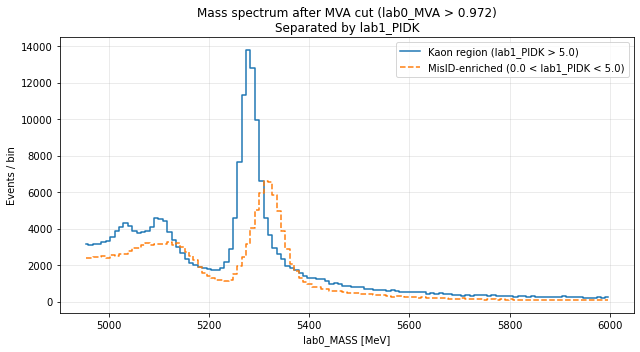

In [18]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# ======================================
# Setup
# ======================================

FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_up_final.root",
]

tree_path     = "Tuple/DecayTree"
mva_branch    = "lab0_MVA"
mass_branch   = "lab0_MASS"
bachelor_pid  = "lab1_PIDK"    # bachelor track PIDK

# Your optimised MVA cut (can relax if you want more stats)
MVA_CUT = 0.972

# PIDK regions to separate DK vs misID π→K
K_LOOSE = 0.0    # lower bound for misID region
K_TIGHT = 5.0    # threshold between misID-enriched and kaon-like

N_BINS = 120

# ======================================
# 1st pass: determine full mass range
# ======================================

mass_min, mass_max = np.inf, -np.inf

for path in FILES:
    with uproot.open(path) as f:
        tree = f[tree_path]
        mass = tree[mass_branch].array(library="np")
        mass_min = min(mass_min, np.min(mass))
        mass_max = max(mass_max, np.max(mass))

print(f"\n📊 Global mass range: {mass_min:.1f} – {mass_max:.1f} MeV")

bin_edges = np.linspace(mass_min, mass_max, N_BINS + 1)

# Histograms for misID pion-enriched and kaon-like regions
hist_misid = np.zeros(N_BINS, dtype=float)
hist_kaon  = np.zeros(N_BINS, dtype=float)

n_misid = 0
n_kaon  = 0

# ======================================
# 2nd pass: apply cuts and fill histograms
# ======================================

for path in FILES:
    print(f"\n🔹 Processing file: {path}")
    with uproot.open(path) as f:
        tree = f[tree_path]

        mva  = tree[mva_branch].array(library="np")
        mass = tree[mass_branch].array(library="np")
        pidk = tree[bachelor_pid].array(library="np")

        # Apply MVA cut first
        mva_mask = mva > MVA_CUT

        mass_cut = mass[mva_mask]
        pidk_cut = pidk[mva_mask]

        # MisID-enriched region: K_LOOSE < PIDK < K_TIGHT
        misid_mask = (pidk_cut > K_LOOSE) & (pidk_cut < K_TIGHT)
        mass_misid = mass_cut[misid_mask]

        # Kaon-like region: PIDK > K_TIGHT
        kaon_mask = pidk_cut > K_TIGHT
        mass_kaon = mass_cut[kaon_mask]

        n_misid += len(mass_misid)
        n_kaon  += len(mass_kaon)

        counts_misid, _ = np.histogram(mass_misid, bins=bin_edges)
        counts_kaon,  _ = np.histogram(mass_kaon,  bins=bin_edges)

        hist_misid += counts_misid
        hist_kaon  += counts_kaon

print(f"\nTotal events after MVA cut & in misID region "
      f"({K_LOOSE} < {bachelor_pid} < {K_TIGHT}): {n_misid}")
print(f"Total events after MVA cut & in kaon region "
      f"({bachelor_pid} > {K_TIGHT}): {n_kaon}")

# ======================================
# Plot: separate misID shape
# ======================================

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure(figsize=(9, 5))

# Kaon-like sample (main DK peak)
plt.step(bin_centers, hist_kaon, where="mid", linestyle="-",
         label=f"Kaon region ({bachelor_pid} > {K_TIGHT})")

# MisID pion-enriched tail
plt.step(bin_centers, hist_misid, where="mid", linestyle="--",
         label=f"MisID-enriched ({K_LOOSE} < {bachelor_pid} < {K_TIGHT})")

plt.xlabel("lab0_MASS [MeV]")
plt.ylabel("Events / bin")
plt.title(f"Mass spectrum after MVA cut (lab0_MVA > {MVA_CUT})\nSeparated by {bachelor_pid}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# -*- coding: utf-8 -*-
# Bd -> D- K+ binned fit on 24c4a up/down final samples with:
#  - FILES: Bd2DK_24c4a_down_final, Bd2DK_24c4a_up_final
#  - MVA cut: lab0_MVA > 0.972 (from your scan)
#  - K-like bachelor sample: lab1_PIDK > 5.0
#  - Bd->DK signal: DSCB (double-sided Crystal Ball)
#  - Bd->Dpi misID: DSCB (double Crystal Ball, shifted)
#  - partial reco gamma (HILLdini) + pi0 (HORNSdini)
#  - Cheby combinatorial model
#  - MASS WINDOW: 4950–6000 MeV

import os, time
import numpy as np
import uproot
import ROOT
from ROOT import RooFit as RF
from IPython.display import Image as IPyImage, display as ipydisplay

# ---------------------------------------------------
# 1. Config: INPUT FILES + switches
# ---------------------------------------------------

DK_FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_up_final.root",
]
assert all(os.path.exists(f) for f in DK_FILES), "One or more DK_FILES do not exist."

TREE_PATH  = "Tuple/DecayTree"

USE_SUBSET = False   # keep False for full stats, True if you want a quick test
SUBSET_N   = 500_000

NBINS      = 600       # fine binning
COMB_MODEL = "cheby"   # "cheby" or "expo"

# physics windows
D_MASS, D_WINDOW = 1869.65, 20.0   # tighter D window
B_END_VCHI2DOF_MAX, D_END_VCHI2DOF_MAX = 5.0, 5.0
BACHELOR_PIDK_MIN = 5.0            # looser than 10.0; tune this if needed
B_FDCHI2_MIN      = 100.0          # B flight distance chi2
B_IPCHI2_MAX      = 15.0           # B IP chi2
B_DIRA_MIN        = 0.9995         # B pointing

# MASS WINDOW
mmin, mmax = 4950., 6000.

# MVA cut (from your scan)
MVA_BRANCH = "lab0_MVA"
MVA_CUT    = 0.9

# ---------------------------------------------------
# 2. ROOT + custom PDFs (HILL / HORNS)
# ---------------------------------------------------
ROOT.gROOT.SetBatch(True)
ROOT.EnableImplicitMT()

# ⚠️ adjust this if your RooHILL/HORNS are somewhere else
base = os.path.expandvars("$HOME/roohill/standalone")
ROOT.gInterpreter.AddIncludePath(os.path.join(base, "include"))
ROOT.gSystem.Load(os.path.join(base, "libRooHILLdini.so"))
ROOT.gSystem.Load(os.path.join(base, "libRooHORNSdini.so"))
print("Custom PDFs loaded:", hasattr(ROOT,"RooHILLdini"), hasattr(ROOT,"RooHORNSdini"))

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kw): return it

# ---------------------------------------------------
# 3. Build DK sample (K-like bachelor, vertex cuts, MVA > 0.972)
# ---------------------------------------------------
vals_all = []

branches = [
    "lab0_MASS", "lab0_END_VCHI2DOF",
    "lab2_END_VCHI2DOF", "lab2_MASS",
    "lab1_PIDK",
    "lab0_BPVFDCHI2", "lab0_BPVIPCHI2", "lab0_BPVDIRA",
    MVA_BRANCH,
]

need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0
t0   = time.time()
print(f"\n[build DK] applying Bd->DK cuts (PIDK>{BACHELOR_PIDK_MIN}, vertex + D mass, "
      f"FDCHI2>{B_FDCHI2_MIN}, IPCHI2<{B_IPCHI2_MAX}, DIRA>{B_DIRA_MIN}, {MVA_BRANCH}>{MVA_CUT})...")

for arrays in tqdm(
    uproot.iterate([f"{fp}:{TREE_PATH}" for fp in DK_FILES],
                   expressions=branches, step_size="60 MB",
                   library="np", allow_missing=False),
    desc="Reading DK tuples"
):
    mB   = arrays["lab0_MASS"]
    bchi = arrays["lab0_END_VCHI2DOF"]
    dchi = arrays["lab2_END_VCHI2DOF"]
    mD   = arrays["lab2_MASS"]
    pidk = arrays["lab1_PIDK"]
    fdchi2 = arrays["lab0_BPVFDCHI2"]
    ipchi2 = arrays["lab0_BPVIPCHI2"]
    dira   = arrays["lab0_BPVDIRA"]
    mva  = arrays[MVA_BRANCH]

    finite = (
        np.isfinite(mB) & np.isfinite(bchi) & np.isfinite(dchi) &
        np.isfinite(mD) & np.isfinite(pidk) &
        np.isfinite(fdchi2) & np.isfinite(ipchi2) & np.isfinite(dira) &
        np.isfinite(mva)
    )

    mB    = mB[finite]
    bchi  = bchi[finite]
    dchi  = dchi[finite]
    mD    = mD[finite]
    pidk  = pidk[finite]
    fdchi2= fdchi2[finite]
    ipchi2= ipchi2[finite]
    dira  = dira[finite]
    mva   = mva[finite]

    sel = (
        (pidk > BACHELOR_PIDK_MIN) &
        (bchi < B_END_VCHI2DOF_MAX) &
        (dchi < D_END_VCHI2DOF_MAX) &
        (np.abs(mD - D_MASS) < D_WINDOW) &
        (fdchi2 > B_FDCHI2_MIN) &
        (ipchi2 < B_IPCHI2_MAX) &
        (dira   > B_DIRA_MIN) &
        (mva    > MVA_CUT)
    )

    v = mB[sel]

    if USE_SUBSET and got < need:
        v = v[: int(max(0, need - got))]
    vals_all.append(v)
    got += v.size
    if got >= need:
        break

vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
vals = vals[(vals > mmin) & (vals < mmax)]
print(f"[build DK] done in {time.time()-t0:.1f}s — kept {vals.size} events after all cuts")

if vals.size == 0:
    raise RuntimeError("No DK events after cuts/subset.")

# ---------------------------------------------------
# 4. Make binned RooDataHist
# ---------------------------------------------------
m  = ROOT.RooRealVar("m","m(B) [MeV/c^{2}]", mmin, mmax)

# seed comb slope sign from low-mass linear fit
side = vals[(vals > 4950) & (vals < 5150)]
if side.size > 10:
    hist_side, edges_side = np.histogram(side, bins=40, range=(4950,5150))
    xmid = 0.5*(edges_side[1:]+edges_side[:-1])
    coef = np.polyfit(xmid, hist_side, 1)[0]
else:
    coef = 0.0

hist, edges = np.histogram(vals, bins=NBINS, range=(mmin,mmax))
dhist = ROOT.TH1D("hDK","hDK", NBINS, mmin, mmax)
for i, y in enumerate(hist, start=1):
    dhist.SetBinContent(i, float(y))
dh = ROOT.RooDataHist("dhDK","binned DK", ROOT.RooArgList(m), dhist)

# ---------------------------------------------------
# 5. Seed mu, sigma for DK signal
# ---------------------------------------------------
focus = vals[(vals>5200)&(vals<5350)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5200,5350))
    edges_f = np.linspace(5200,5350,81)
    xmid_f  = 0.5*(edges_f[1:]+edges_f[:-1])
    mu0   = xmid_f[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals[(vals>mu0-40)&(vals<mu0+40)]
sig0 = np.std(selp) if selp.size>1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))

# ---------------------------------------------------
# 6. Physics model for Bd -> DK
# ---------------------------------------------------

# DK signal: DSCB (left+right CB)
mu  = ROOT.RooRealVar("mu","DK mean", mu0, mu0-20., mu0+20.)
sig = ROOT.RooRealVar("sig","DK sigma", sig0, 8., 25.)

aL,nL = ROOT.RooRealVar("aL","aL",1.6,0.5,5), ROOT.RooRealVar("nL","nL",4,1,20)
sigL  = ROOT.RooCBShape("sigL","left CB DK",  m, mu, sig, aL, nL)
aR,nR = ROOT.RooRealVar("aR","aR",-2.0,-6,-0.5), ROOT.RooRealVar("nR","nR",3,1,20)
sigR  = ROOT.RooCBShape("sigR","right CB DK", m, mu, sig, aR, nR)
fLR   = ROOT.RooRealVar("fLR","frac left",0.5,0.1,0.9)
SIG   = ROOT.RooAddPdf("SIG","DSCB_DK", ROOT.RooArgList(sigL, sigR), ROOT.RooArgList(fLR))

# -------- Bd->Dπ mis-ID component: DSCB (double CB) shifted --------
dMis   = ROOT.RooRealVar("dMis","D#pi->DK shift",50.0,30.0,80.0)
mu_mis = ROOT.RooFormulaVar("mu_mis","@0+@1", ROOT.RooArgList(mu,dMis))

sig_mis = ROOT.RooRealVar("sig_mis","misID width",1.4*sig0, sig0, 3.0*sig0)

aL_mis = ROOT.RooRealVar("aL_mis","aL_mis",1.5,0.5,5.0)
nL_mis = ROOT.RooRealVar("nL_mis","nL_mis",3.0,1.0,20.0)
MIS_L  = ROOT.RooCBShape("MIS_L","misID left CB",  m, mu_mis, sig_mis, aL_mis, nL_mis)

aR_mis = ROOT.RooRealVar("aR_mis","aR_mis",-1.5,-8.0,-0.2)  # negative -> right tail
nR_mis = ROOT.RooRealVar("nR_mis","nR_mis",3.0,1.0,20.0)
MIS_R  = ROOT.RooCBShape("MIS_R","misID right CB", m, mu_mis, sig_mis, aR_mis, nR_mis)

fLR_mis = ROOT.RooRealVar("fLR_mis","frac left misID",0.5,0.1,0.9)
MIS = ROOT.RooAddPdf("MIS","misID Bd->D#pi (DSCB)",
                     ROOT.RooArgList(MIS_L, MIS_R),
                     ROOT.RooArgList(fLR_mis))

# partial reco gamma (HILLdini) and pi0 (HORNSdini)
h_a  = ROOT.RooRealVar("h_a","HILL a",4950,4900,5150)
dHb  = ROOT.RooRealVar("dHb","Δ_HILL",140,70,240)
h_b  = ROOT.RooFormulaVar("h_b","@0-@1", ROOT.RooArgList(mu,dHb))
h_c  = ROOT.RooRealVar("h_csi","HILL csi",0.45,0,1)
h_sh = ROOT.RooRealVar("h_shift","HILL shift",0.0)
h_sg = ROOT.RooRealVar("h_sigma","HILL sigma",22,8,40)
h_rs = ROOT.RooRealVar("h_rs","HILL ratio_sigma",2.0,1.2,3.5)
h_fs = ROOT.RooRealVar("h_fs","HILL fraction_sigma",0.5,0.2,0.8)
BKG_g = ROOT.RooHILLdini("BKG_g","gamma-like", m, h_a,h_b,h_c,h_sh,h_sg,h_rs,h_fs)

r_a  = ROOT.RooRealVar("r_a","HORNS a",5020,4950,5200)
dRb  = ROOT.RooRealVar("dRb","Δ_HORNS",90,40,180)
r_b  = ROOT.RooFormulaVar("r_b","@0-@1", ROOT.RooArgList(mu,dRb))
r_c  = ROOT.RooRealVar("r_csi","HORNS csi",0.30,0,1)
r_sh = ROOT.RooRealVar("r_shift","HORNS shift",0.0)
r_sg = ROOT.RooRealVar("r_sigma","HORNS sigma",24,8,45)
r_rs = ROOT.RooRealVar("r_rs","HORNS ratio_sigma",2.0,1.2,3.5)
r_fs = ROOT.RooRealVar("r_fs","HORNS fraction_sigma",0.5,0.2,0.8)
BKG_pi = ROOT.RooHORNSdini("BKG_pi","pi0-like", m, r_a,r_b,r_c,r_sh,r_sg,r_rs,r_fs)

# combinatorial
if COMB_MODEL == "expo":
    b = ROOT.RooRealVar("b_slope","expo slope",
                        -1e-3 if coef<=0 else 1e-3, -5e-3, 5e-3)
    BKG_comb = ROOT.RooExponential("BKG_comb","comb", m, b)
else:
    c0 = ROOT.RooRealVar("c0","c0", 0.0, -1.0, 1.0)
    c1 = ROOT.RooRealVar("c1","c1", -0.10 if coef<=0 else 0.10, -1.0, 1.0)
    c2 = ROOT.RooRealVar("c2","c2", 0.0, -1.0, 1.0)
    BKG_comb = ROOT.RooChebychev("BKG_comb","comb", m, ROOT.RooArgList(c0,c1,c2))

# yields
Ntot  = float(np.sum(hist))
Nsig  = ROOT.RooRealVar("Nsig","DK signal yield",  0.35*Ntot, 0.0, 2.0*Ntot)
Nmis  = ROOT.RooRealVar("Nmis","Dpi misID yield",  0.05*Ntot, 0.0, 0.5*Ntot)
Ng    = ROOT.RooRealVar("Ng",  "gamma yield",      0.04*Ntot, 0.0, 1.0*Ntot)
Npi   = ROOT.RooRealVar("Npi", "pi0 yield",        0.02*Ntot, 0.0, 1.0*Ntot)
Ncomb = ROOT.RooRealVar("Ncomb","comb yield",      0.54*Ntot, 0.0, 2.0*Ntot)

# ---------------------------------------------------
# 7. Sideband comb pre-fit + constraints
# ---------------------------------------------------
m.setRange("LSB", 4950, 5150)
m.setRange("RSB", 5600, 6000)

print("\n[sidebands] fitting comb-only in LSB+RSB...")
_ = BKG_comb.fitTo(dh, RF.Range("LSB,RSB"), RF.PrintLevel(-1))

constraints = ROOT.RooArgSet()

def _attach_shape_constraint(param, rel=0.30, floor=1e-4):
    val = param.getVal()
    sigma = max(rel*abs(val), floor)
    g = ROOT.RooGaussian(f"g_{param.GetName()}","comb prior",
                         param, RF.RooConst(val), RF.RooConst(sigma))
    constraints.addOwned(g)

if COMB_MODEL == "expo":
    _attach_shape_constraint(b, rel=0.30, floor=1e-5)
else:
    for p in (c0,c1,c2):
        _attach_shape_constraint(p, rel=0.30, floor=1e-4)

mu_Ng,  sig_Ng  = 0.04*Ntot, max(1.0, 0.04*Ntot)
mu_Npi, sig_Npi = 0.02*Ntot, max(1.0, 0.02*Ntot)
gNg  = ROOT.RooGaussian("gNg","weak prior Ng",  Ng,  RF.RooConst(mu_Ng),  RF.RooConst(sig_Ng))
gNpi = ROOT.RooGaussian("gNpi","weak prior Npi", Npi, RF.RooConst(mu_Npi), RF.RooConst(sig_Npi))
constraints.addOwned(gNg); constraints.addOwned(gNpi)

# ---------------------------------------------------
# 8. Prefit DK signal + comb (freeze DSCB tails), then freeze mu,sig
# ---------------------------------------------------
for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(True)

pdf_pre = ROOT.RooAddPdf("pdf_pre_DK","pre_DK",
                         ROOT.RooArgList(SIG,BKG_comb),
                         ROOT.RooArgList(Nsig,Ncomb))
print("\n[prefit DK] signal+comb (DSCB, tails frozen)...")
_ = pdf_pre.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Minimizer("Minuit2","Migrad"),
    RF.PrintLevel(-1),
)

mu.setConstant(True)
sig.setConstant(True)

for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(False)

# ---------------------------------------------------
# 9. Full DK fit: DK signal + Dπ misID (DSCB) + gamma + pi0 + comb
# ---------------------------------------------------
pdf = ROOT.RooAddPdf("pdf_DK","DK model",
                     ROOT.RooArgList(SIG, MIS, BKG_g, BKG_pi, BKG_comb),
                     ROOT.RooArgList(Nsig, Nmis, Ng, Npi, Ncomb))

print("\n[fit DK] final binned extended likelihood, NBINS =", NBINS)
tfit = time.time()
fitres = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Migrad"),
    RF.Save(True),
    RF.PrintLevel(-1),
)
_ = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Hesse"),
    RF.Save(True),
    RF.PrintLevel(-1),
)

print(f"[fit DK] time: {time.time()-tfit:.1f}s, status={fitres.status()}, covQual={fitres.covQual()}")

# ---------------------------------------------------
# 10. Plot
# ---------------------------------------------------
frame = m.frame(RF.Title(f"B^{{0}} #rightarrow D^-K^+ invariant-mass fit (binned, {MVA_BRANCH}>{MVA_CUT:.3f})"))
dh.plotOn(frame, RF.Name("data"))
pdf.plotOn(frame, RF.LineColor(ROOT.kBlue+1), RF.LineWidth(3), RF.Name("total"))
pdf.plotOn(frame, RF.Components("SIG"),      RF.LineColor(ROOT.kRed),        RF.LineWidth(2), RF.Name("sig_line"))
pdf.plotOn(frame, RF.Components("MIS"),      RF.LineColor(ROOT.kViolet+2),   RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("mis_line"))
pdf.plotOn(frame, RF.Components("BKG_g"),    RF.LineColor(ROOT.kMagenta+1),  RF.LineStyle(ROOT.kDashed),     RF.LineWidth(2), RF.Name("hill_line"))
pdf.plotOn(frame, RF.Components("BKG_pi"),   RF.LineColor(ROOT.kOrange+7),   RF.LineStyle(ROOT.kDotted),     RF.LineWidth(2), RF.Name("horn_line"))
pdf.plotOn(frame, RF.Components("BKG_comb"), RF.LineColor(ROOT.kGreen+2),    RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("comb_line"))

c = ROOT.TCanvas(f"c_DK_{int(time.time())}","DKFit",1000,620)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.Draw()

leg = ROOT.TLegend(0.58, 0.64, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),  "Data",                       "pe")
leg.AddEntry(frame.findObject("total"), "Total fit",                  "l")
leg.AddEntry(frame.findObject("sig_line"),   "Signal Bd#rightarrowDK (DSCB)", "l")
leg.AddEntry(frame.findObject("mis_line"),   "misID Bd#rightarrowD#pi (DSCB)",  "l")
leg.AddEntry(frame.findObject("hill_line"),  "Part.-reco #gamma (HILLdini)",  "l")
leg.AddEntry(frame.findObject("horn_line"),  "Part.-reco #pi^{0} (HORNSdini)","l")
leg.AddEntry(frame.findObject("comb_line"),  "Combinatorial",                 "l")
leg.Draw()

box = ROOT.TPaveText(0.58, 0.15, 0.93, 0.40, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText(f"#bf{{Bd#rightarrowDK fit ({MVA_BRANCH}>{MVA_CUT:.3f})}}")
box.AddText(f"Mean  #mu = {mu.getValV():.1f} #pm {mu.getError():.1f} MeV")
box.AddText(f"Width #sigma = {sig.getValV():.1f} #pm {sig.getError():.3f} MeV")
t = box.AddText(f"DK signal = {Nsig.getValV():.0f} #pm {Nsig.getError():.0f}"); t.SetTextColor(ROOT.kRed)
t = box.AddText(f"D#pi misID = {Nmis.getValV():.0f} #pm {Nmis.getError():.0f}"); t.SetTextColor(ROOT.kViolet+2)
t = box.AddText(f"#gamma-like = {Ng.getValV():.0f} #pm {Ng.getError():.0f}"); t.SetTextColor(ROOT.kMagenta+1)
t = box.AddText(f"#pi^{0}-like = {Npi.getValV():.0f} #pm {Npi.getError():.0f}"); t.SetTextColor(ROOT.kOrange+7)
t = box.AddText(f"Comb. = {Ncomb.getValV():.0f} #pm {Ncomb.getError():.0f}"); t.SetTextColor(ROOT.kGreen+2)
box.Draw()

c.Modified(); c.Update(); ROOT.gSystem.ProcessEvents()
tmp_png = f"/tmp/fit_DK_MVAcut_{int(time.time())}.png"
c.SaveAs(tmp_png)
try:
    ipydisplay(IPyImage(filename=tmp_png))
except Exception:
    print(f"Saved DK fit plot to {tmp_png}")


Welcome to JupyROOT 6.30/02
Custom PDFs loaded: True True

[build DK] applying Bd->DK cuts (PIDK>5.0, vertex + D mass, FDCHI2>100.0, IPCHI2<15.0, DIRA>0.9995, lab0_MVA>0.5)...



Reading DK tuples: 2it [00:06,  3.07s/it]



[build DK] done in 6.2s — kept 306507 events after all cuts

[sidebands] fitting comb-only in LSB+RSB...[#1] INFO:Eval -- RooRealVar::setRange(m) new range named 'LSB' created with bounds [4950,5150]

[prefit DK] signal+comb (DSCB, tails frozen)...
2,c2 = 0.678572)


[70 RooFit INFO/Eval messages suppressed for readability]


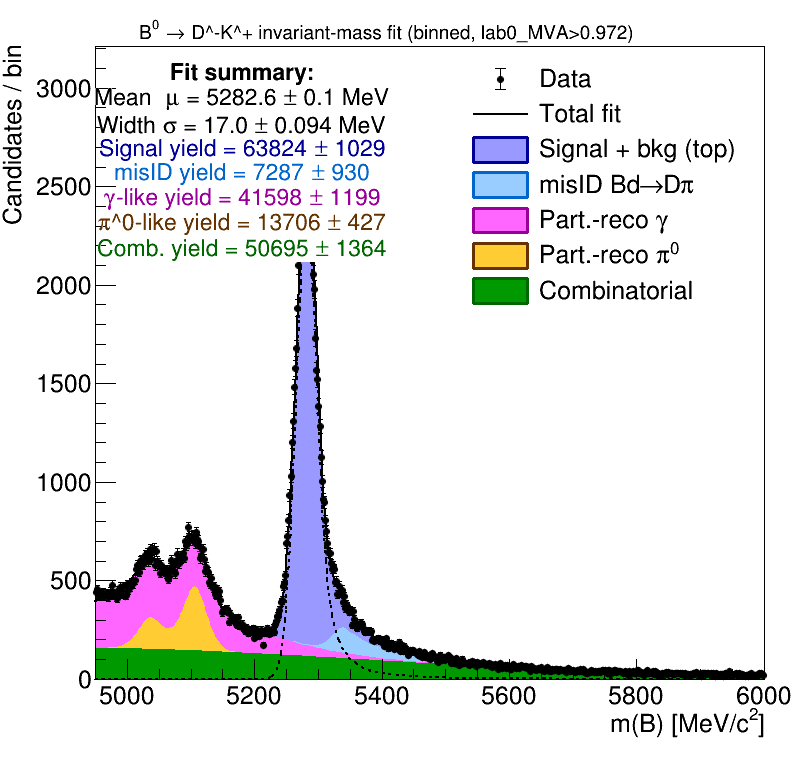



[26 RooFit INFO/Eval messages suppressed for readability]


Info in <TCanvas::Print>: png file /tmp/fit_DK_1762779216.png has been created



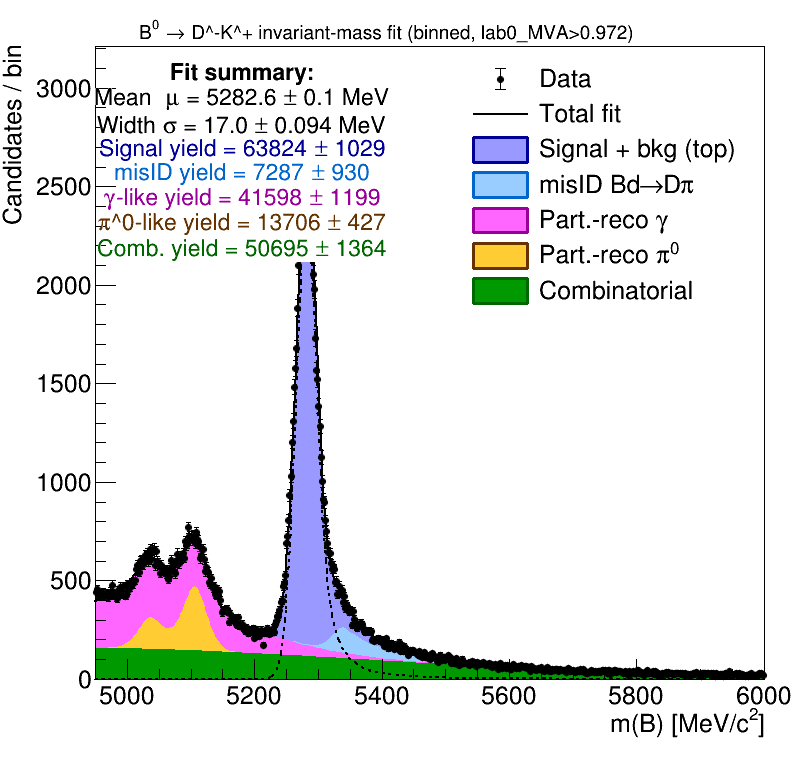

In [22]:
# ---------------------------------------------------
# 10. Plot – stacked filled components (Bd -> D^- K^+)
# ---------------------------------------------------
frame = m.frame(
    RF.Title(f"B^{{0}} #rightarrow D^-K^+ invariant-mass fit (binned, {MVA_BRANCH}>{MVA_CUT:.3f})")
)

# data points
dh.plotOn(
    frame,
    RF.Name("data"),
    RF.MarkerStyle(20),
    RF.MarkerSize(0.8),
    RF.LineColor(ROOT.kBlack)
)

# --- STACKED FILLS (cumulative sums of components) ---
# Order: comb → comb+pi0 → comb+pi0+gamma → ... so there is no white space.

# 1) combinatorial only (green)
pdf.plotOn(
    frame,
    RF.Components("BKG_comb"),
    RF.Name("comb_stack"),
    RF.FillColor(ROOT.kGreen+2),
    RF.FillStyle(1001),
    RF.LineColor(ROOT.kGreen+3),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 2) comb + pi0-like (orange)
pdf.plotOn(
    frame,
    RF.Components("BKG_comb,BKG_pi"),
    RF.Name("pi0_stack"),
    RF.FillColor(ROOT.kOrange-2),
    RF.FillStyle(1001),
    RF.LineColor(ROOT.kOrange+3),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 3) comb + pi0-like + gamma-like (magenta)
pdf.plotOn(
    frame,
    RF.Components("BKG_comb,BKG_pi,BKG_g"),
    RF.Name("gamma_stack"),
    RF.FillColor(ROOT.kMagenta-7),
    RF.FillStyle(1001),
    RF.LineColor(ROOT.kMagenta+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 4) comb + pi0-like + gamma-like + misID (light blue)
pdf.plotOn(
    frame,
    RF.Components("BKG_comb,BKG_pi,BKG_g,MIS"),
    RF.Name("mis_stack"),
    RF.FillColor(ROOT.kAzure-9),
    RF.FillStyle(1001),
    RF.LineColor(ROOT.kAzure+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 5) FULL MODEL (all components, incl. signal) – top region (dark blue)
pdf.plotOn(
    frame,
    RF.Components("BKG_comb,BKG_pi,BKG_g,MIS,SIG"),
    RF.Name("sig_stack"),
    RF.FillColor(ROOT.kBlue-9),
    RF.FillStyle(1001),
    RF.LineColor(ROOT.kBlue+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# --- Lines on top (nice black curves) ---

# total model line
pdf.plotOn(
    frame,
    RF.Name("total"),
    RF.LineColor(ROOT.kBlack),
    RF.LineWidth(2)
)

# (optional) signal line only (black dashed)
pdf.plotOn(
    frame,
    RF.Components("SIG"),
    RF.Name("sig_line"),
    RF.LineColor(ROOT.kBlack),
    RF.LineStyle(ROOT.kDashed),
    RF.LineWidth(2)
)

# canvas & axes
c = ROOT.TCanvas(f"c_DK_{int(time.time())}","DKFit",800,800)
c.SetLeftMargin(0.12)
c.SetRightMargin(0.04)
c.SetTopMargin(0.06)
c.SetBottomMargin(0.12)

frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.SetMinimum(0)                          # fill from y=0 up
frame.SetMaximum(1.15 * frame.GetMaximum())  # use vertical space nicely
frame.Draw()

# legend (note: entries refer to stacked fills)
leg = ROOT.TLegend(0.58, 0.60, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),      "Data",                      "pe")
leg.AddEntry(frame.findObject("total"),     "Total fit",                 "l")
leg.AddEntry(frame.findObject("sig_stack"), "Signal + bkg (top)",        "f")
leg.AddEntry(frame.findObject("mis_stack"), "misID Bd#rightarrowD#pi",   "f")
leg.AddEntry(frame.findObject("gamma_stack"),"Part.-reco #gamma",        "f")
leg.AddEntry(frame.findObject("pi0_stack"), "Part.-reco #pi^{0}",        "f")
leg.AddEntry(frame.findObject("comb_stack"),"Combinatorial",             "f")
leg.Draw()

# fit-summary box
box = ROOT.TPaveText(0.16, 0.66, 0.45, 0.92, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText("#bf{Fit summary:}")
box.AddText(f"Mean  #mu = {mu.getValV():.1f} #pm {mu.getError():.1f} MeV")
box.AddText(f"Width #sigma = {sig.getValV():.1f} #pm {sig.getError():.3f} MeV")
t = box.AddText(f"Signal yield = {Nsig.getValV():.0f} #pm {Nsig.getError():.0f}"); t.SetTextColor(ROOT.kBlue+2)
t = box.AddText(f"misID yield = {Nmis.getValV():.0f} #pm {Nmis.getError():.0f}"); t.SetTextColor(ROOT.kAzure+2)
t = box.AddText(f"#gamma-like yield = {Ng.getValV():.0f} #pm {Ng.getError():.0f}"); t.SetTextColor(ROOT.kMagenta+2)
t = box.AddText(f"#pi^{0}-like yield = {Npi.getValV():.0f} #pm {Npi.getError():.0f}"); t.SetTextColor(ROOT.kOrange+3)
t = box.AddText(f"Comb. yield = {Ncomb.getValV():.0f} #pm {Ncomb.getError():.0f}"); t.SetTextColor(ROOT.kGreen+3)
box.Draw()

c.Modified(); c.Update(); ROOT.gSystem.ProcessEvents()
tmp_png = f"/tmp/fit_DK_{int(time.time())}.png"
c.SaveAs(tmp_png)
try:
    ipydisplay(IPyImage(filename=tmp_png))
except Exception:
    print(f"Saved plot to {tmp_png}")
